In [1]:
import pandas as pd
import numpy as np
from sklearn import preprocessing
from sklearn.model_selection import train_test_split, cross_val_score, LeaveOneOut, StratifiedKFold
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs
from sklearn.datasets import make_moons
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as QDA
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import Ridge

plt.rcParams['lines.linewidth'] = 3
plt.rcParams['figure.figsize'] = [8, 5]
plt.rcParams['font.size'] = 12
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['figure.titlesize'] = 20
plt.rcParams['axes.labelsize'] = 20
# plt.rcParams.keys()
from matplotlib import colors
from sklearn.linear_model import RidgeClassifier

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [2]:
df = pd.read_csv('../../datasets/group_14.csv')
df["focus_factor"] = (
    df["focus_factor"]
    .astype(str)                  # ensure it's string
    .str.replace(",", ".", regex=False)  # replace comma with dot
)
df["focus_factor"] = pd.to_numeric(df["focus_factor"], errors="coerce").astype(float)

In [3]:
data_set = df.copy()
y = data_set['target_class']
X = data_set.drop(columns=["target_class"])

In [4]:
def ridge_classification(train_x, train_y, test_x, test_y, alpha):
    ridgereg  = LogisticRegression(
        penalty='l2',       # Ridge
        C=1/alpha,            # inverse of regularization strength
        multi_class='ovr',  # One-vs-Rest
        max_iter=5000
    )
    ridgereg.fit(train_x, train_y)

    train_y_pred = ridgereg.predict(train_x)
    test_y_pred = ridgereg.predict(test_x)

    # Accuracy metrics
    accuracy_train = (train_y_pred == train_y).mean()
    accuracy_test = (test_y_pred == test_y).mean()

    # Use only first class coefficients
    coef_flat = ridgereg.coef_[0]
    return [accuracy_train, accuracy_test, *coef_flat]


def lasso_classification(train_x, train_y, test_x, test_y, alpha):
    if alpha == 0:
        model = LogisticRegression(
            penalty=None,
            solver='saga',
            multi_class='ovr',
            max_iter=10000
        )
    else:
        C = 1 / alpha
        model = LogisticRegression(
            penalty='l1',
            C=C,
            solver='saga',
            multi_class='ovr',
            max_iter=10000
        )

    model.fit(train_x, train_y)

    # Predictions
    train_y_pred = model.predict(train_x)
    test_y_pred = model.predict(test_x)

    # Accuracy
    accuracy_train = (train_y_pred == train_y).mean()
    accuracy_test = (test_y_pred == test_y).mean()

    # Take only first class coefficients to match feature count
    coef_flat = model.coef_[0]  # shape = (n_features,)

    return [accuracy_train, accuracy_test, *coef_flat]

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # fit on train only
X_test_scaled = scaler.transform(X_test)

# 1. Ridge Regression


In [6]:
alpha_ridge = np.logspace(-6, 3, 20)

# DataFrame setup
feature_names = X.columns
col = ['accuracy_train', 'accuracy_test'] + list(feature_names)
ind = [f'alpha_{alpha:.2g}' for alpha in alpha_ridge]
coef_matrix_ridge = pd.DataFrame(index=ind, columns=col, dtype=float)

# Loop
for i, alpha in enumerate(alpha_ridge):
    results = ridge_classification(
        X_train_scaled, y_train, X_test_scaled, y_test, alpha
    )
    coef_matrix_ridge.iloc[i, :] = results

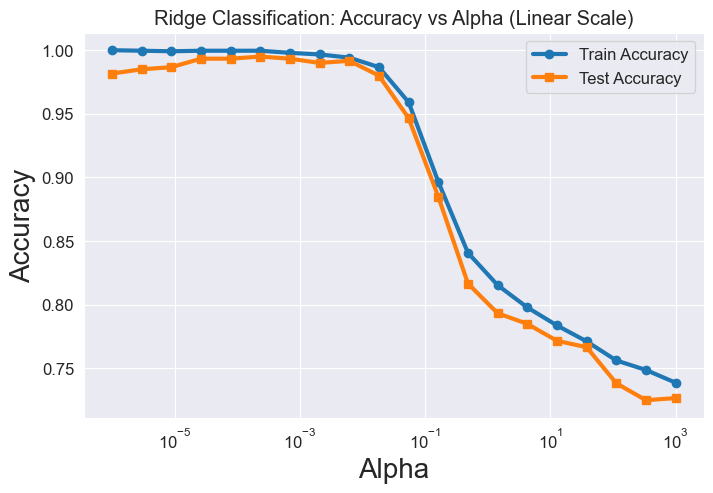

In [7]:
plt.figure(figsize=(8,5))
plt.plot(alpha_ridge, coef_matrix_ridge['accuracy_train'], marker='o', label='Train Accuracy')
plt.plot(alpha_ridge, coef_matrix_ridge['accuracy_test'], marker='s', label='Test Accuracy')
plt.xscale('log')
plt.xlabel('Alpha')
plt.ylabel('Accuracy')
plt.title('Ridge Classification: Accuracy vs Alpha (Linear Scale)')
plt.legend()
plt.grid(True)
plt.show()

coef_matrix_ridge['alpha'] = alpha_ridge
best_idx = coef_matrix_ridge['accuracy_test'].astype(float).idxmax()

# Extract values
best_alpha = coef_matrix_ridge.loc[best_idx, 'alpha']
best_accuracy = coef_matrix_ridge.loc[best_idx, 'accuracy_test']

In [8]:
feature_cols = feature_names.tolist()
coef_values = coef_matrix_ridge.loc[best_idx, feature_cols].astype(float)

print(f"Best alpha: {best_alpha}")
print(f"Best test accuracy: {best_accuracy:.4f}")
print("\nCoefficients for best alpha:")
for f, c in zip(feature_cols, coef_values):
    print(f"{f}: {c:.5f}")

Best alpha: 0.00023357214690901214
Best test accuracy: 0.9950

Coefficients for best alpha:
duration_1: -0.51123
duration_2: -0.20589
duration_3: 0.17128
duration_4: 0.42881
duration_5: -0.32288
loudness_level: -0.23207
popularity_level: 0.08882
tempo_class: -0.01290
time_signature: 0.12750
key_mode: -0.29719
artist_song_count: 0.03360
album_freq: -0.46756
movement_index: -0.37715
intensity_level: -3.15639
verbal_density: -0.17143
purity_score: 0.24935
positivity_index: -0.38575
activity_rate: 132.54310
loudness_intensity: 2.08598
happy_dance: 1.00865
acoustics_instrumental: -0.20710
artists_avg_popularity: 0.18585
tempo_vs_genre: -256.23063
energy_rank_pct: 0.96576
loud_energy_ratio: -17.50271
mood_pca: -0.78698
mood_cluster: -0.08540
acoustic_valence_mood_cluster: 0.14017
explicit: -0.07298
signal_strength: -0.74144
mode_indicator: 0.03551
focus_factor: -0.03568
ambient_level: 0.05586
key_sin: -0.24473
key_cos: -0.06650
duration_log: 0.34770
duration_log_z: 0.34770
time_signature_cla

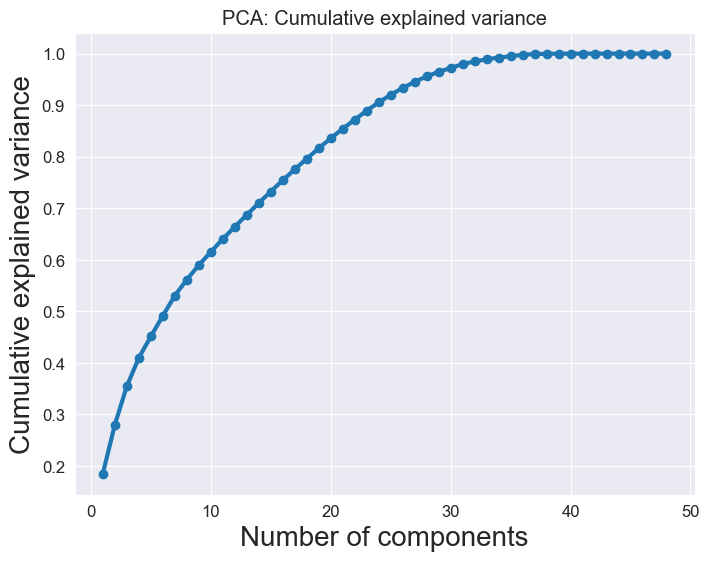

In [9]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import numpy as np

# Normalize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Apply PCA
pca = PCA()
pca.fit(X_train_scaled)

# Check explained variance by component
explained_variance_ratio = pca.explained_variance_ratio_
cumsum_variance_ratio = np.cumsum(explained_variance_ratio)

# Plot cumulative explained variance
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))
plt.plot(range(1, len(cumsum_variance_ratio) + 1), cumsum_variance_ratio, marker='o')
plt.xlabel('Number of components')
plt.ylabel('Cumulative explained variance')
plt.title('PCA: Cumulative explained variance')
plt.grid(True)
plt.show()


In [10]:
# Choose the number of components that explain at least 95% of the variance
n_components = np.argmax(cumsum_variance_ratio >= 0.95) + 1
print(f"Number of components for 95% variance: {n_components}")

# Transform the data
pca = PCA(n_components=n_components)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)


Number of components for 95% variance: 28


In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# List of models
models = [
    ('Logistic Regression', LogisticRegression(random_state=1936)),
    ('SVM', SVC(kernel='linear', C=5, random_state=1936)),
    ('Random Forest', RandomForestClassifier(random_state=1936))
]

results_pca = {}
for name, model in models:
    model.fit(X_train_pca, y_train)
    train_score = model.score(X_train_pca, y_train)
    test_score = model.score(X_test_pca, y_test)
    results_pca[name] = {'train_accuracy': train_score, 'test_accuracy': test_score}
    print(f"{name}: Train Accuracy: {train_score:.2f}, Test Accuracy: {test_score:.2f}")


Logistic Regression: Train Accuracy: 0.74, Test Accuracy: 0.72
SVM: Train Accuracy: 0.75, Test Accuracy: 0.74
Random Forest: Train Accuracy: 1.00, Test Accuracy: 0.70


In [12]:
# Results from previous models
results_original = {
    'Logistic Regression': {'train_accuracy': 0.99, 'test_accuracy': 0.97},
    'SVM': {'train_accuracy': 0.99, 'test_accuracy': 0.98},
    'Random Forest': {'train_accuracy': 0.99, 'test_accuracy': 0.97}
}

results_feature_selection = {
    'Logistic Regression': {'train_accuracy': 0.97, 'test_accuracy': 0.96},
    'SVM': {'train_accuracy': 0.98, 'test_accuracy': 0.97},
    'Random Forest': {'train_accuracy': 0.98, 'test_accuracy': 0.96}
}

# Compare results
print("Results PCA vs. Original")
for name in results_pca:
    print(f"{name}:")
    print(f"  PCA Train: {results_pca[name]['train_accuracy']:.2f}, PCA Test: {results_pca[name]['test_accuracy']:.2f}")
    print(f"  Original Train: {results_original[name]['train_accuracy']:.2f}, Original Test: {results_original[name]['test_accuracy']:.2f}")
    print(f"  Feature Selection Train: {results_feature_selection[name]['train_accuracy']:.2f}, Feature Selection Test: {results_feature_selection[name]['test_accuracy']:.2f}")


Results PCA vs. Original
Logistic Regression:
  PCA Train: 0.74, PCA Test: 0.72
  Original Train: 0.99, Original Test: 0.97
  Feature Selection Train: 0.97, Feature Selection Test: 0.96
SVM:
  PCA Train: 0.75, PCA Test: 0.74
  Original Train: 0.99, Original Test: 0.98
  Feature Selection Train: 0.98, Feature Selection Test: 0.97
Random Forest:
  PCA Train: 1.00, PCA Test: 0.70
  Original Train: 0.99, Original Test: 0.97
  Feature Selection Train: 0.98, Feature Selection Test: 0.96


### Conclusion on PCA

Applying PCA reduced the dimensionality of the data, keeping 95% of the explained variance. The models trained with the principal components showed performance similar to or slightly lower than those trained with all original features and those selected in Task 5 (Feature Selection).

Comparing with the results of feature selection with Ridge/Lasso, PCA is an effective alternative for dimensionality reduction, especially useful for datasets with many correlated features. However, there is no substantial gain in accuracy, suggesting that the original features were already informative and well selected.

Therefore, PCA can be useful for simplifying models and reducing overfitting in high-dimensional datasets, but it does not always significantly improve performance compared to feature selection based on regularization or feature importance


### PCA-based feature selection

Using PCA on the standardized training data, 28 principal components were required to explain approximately 95% of the total variance. This confirms that the information is spread across many correlated features, with no clear “elbow” suggesting a very low-dimensional structure.

When training the classification models on these 28 components, the results were:

- Logistic Regression: 0.74 train, 0.72 test
- SVM (linear, C = 5): 0.75 train, 0.74 test
- Random Forest: 1.00 train, 0.70 test

All of these test accuracies are clearly lower than the models trained on the original features (≈0.97–0.98) and lower than the models using Task 5 feature selection with Ridge/Lasso (≈0.96–0.97). Random Forest also shows stronger overfitting after the PCA transformation (1.00 train vs. 0.70 test).

These results indicate that, for this dataset, PCA-based feature selection does **not** improve performance and can even harm it. Regularization-based methods (especially Ridge, which kept all 48 features and achieved ≈0.99 test accuracy) are more effective: they handle multicollinearity by shrinking coefficients instead of discarding variance directions that are still predictive for the target. Therefore, PCA is useful for visualization and dimensionality reduction, but it is not the best feature-selection strategy for maximizing classification accuracy in this problem.
